# Notebook 3: Modelo generativo 1 — Ruido ("muy tonto")

Primer modelo generativo, el método de referencia obligatorio del taller:
$\hat{x} = x + \text{ruido}$.

Actúa sobre los tres componentes de la descomposición factorial (Notebook
2): factor de mercado, factores sectoriales, componentes idiosincráticos.
Cada componente recibe ruido gaussiano independiente, escalado según su
propia volatilidad histórica. Después se reconstruyen los retornos
sintéticos de los 30 activos sumando los tres componentes perturbados con
las betas reales (`reconstruct_returns`, ya usado en el Notebook 2 para la
comprobación de consistencia).

Este notebook sirve de plantilla para los siguientes (Gaussiana ajustada,
VAE, AR/GRU): todos seguirán la misma estructura — generar componentes
sintéticos, reconstruir retornos, comparar con los reales.

**Por qué actuar sobre los componentes y no sobre los retornos en bruto:**
el enunciado del taller pide un modelo simple que "coja datos originales y
les añada ruido" — la forma más literal sería sumar ruido directamente a
los retornos de los 30 activos, sin pasar por ninguna descomposición.
Se descartó esa opción deliberadamente: el objetivo del proyecto no es
solo generar datos parecidos a los reales, sino poder simular después
escenarios condicionados ("más volatilidad en banca", "shock en un activo
concreto"), y eso únicamente es posible si el ruido se aplica sobre las
piezas ya separadas (mercado / sector / idiosincrático) — perturbar los
retornos en bruto no daría ninguna palanca para dirigir el efecto a un
sector o activo en particular. Por eso, incluso el modelo más simple del
taller sigue esta estructura por componentes: no es una complicación
gratuita, es la base que hace posible el resto del proyecto (Notebook 2 en
adelante), y mantiene la misma interfaz que usarán los modelos más
sofisticados.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.factors.decomposition import reconstruct_returns
from src.generators.noise import add_gaussian_noise, generate_synthetic_components_noise

## 1. Cargar los componentes reales (Notebook 2)

In [2]:
returns_real = pd.read_parquet("../data/processed/returns_daily.parquet")
market_factor = pd.read_parquet("../data/processed/market_factor.parquet")["market_factor"]
sector_factors = pd.read_parquet("../data/processed/sector_factors.parquet")
idiosyncratic = pd.read_parquet("../data/processed/idiosyncratic_returns.parquet")
betas = pd.read_parquet("../data/processed/factor_betas.parquet")

print(f"Retornos reales: {returns_real.shape}")
print(f"Factor de mercado: {market_factor.shape}")
print(f"Factores sectoriales: {sector_factors.shape}")
print(f"Componentes idiosincráticos: {idiosyncratic.shape}")

Retornos reales: (2785, 30)
Factor de mercado: (2785,)
Factores sectoriales: (2785, 30)
Componentes idiosincráticos: (2785, 30)


## 2. Generar componentes sintéticos con ruido

**Elección de `noise_std_ratio`:** con ruido aditivo independiente, la
varianza del resultado es siempre `Var(real) + Var(ruido)`. Si
`noise_std_ratio=1.0` (ruido con la misma desviación que la serie
original), la desviación del sintético queda en
$\sqrt{1^2+1^2}=\sqrt{2}\approx 1.41$ veces la real — una primera prueba
con ese valor lo confirmó exactamente: todos los activos salieron con
`std_ratio` entre 1.41 y 1.45, un ~41% de exceso sistemático de
volatilidad, y una diferencia media de correlación real-sintético de 0.042
(máxima 0.223). No es un baseline fiel a la descripción del enunciado
("coja datos originales y les añada ruido", no "duplique la varianza").

Se bajó a `noise_std_ratio=0.2` (dentro del rango 0.1-0.3 habitual para
este tipo de baseline), lo que reduce el exceso esperado de volatilidad a
$\sqrt{1+0.2^2}-1\approx 2\%$ — resultado confirmado en la sección 4.

In [3]:
NOISE_STD_RATIO = 0.2
SEED = 42

synthetic_components = generate_synthetic_components_noise(
    market_factor, sector_factors, idiosyncratic,
    noise_std_ratio=NOISE_STD_RATIO, seed=SEED,
)

market_factor_synth = synthetic_components["market_factor"]
sector_factors_synth = synthetic_components["sector_factors"]
idiosyncratic_synth = synthetic_components["idiosyncratic"]

## 3. Reconstruir retornos sintéticos

Se reutilizan las betas REALES (estimadas en el Notebook 2): el modelo de
ruido no aprende ninguna relación entre activos, solo perturba los
componentes ya descompuestos. La estructura de exposición a mercado/sector
de cada activo se mantiene igual que en los datos reales.

In [4]:
returns_synthetic = reconstruct_returns(
    market_factor_synth, sector_factors_synth, idiosyncratic_synth, betas
)
returns_synthetic.head()

,AAL,AAPL,AMD,AMZN,B,BAC,BMY,C,CLF,CSX,...,NEE,NVDA,OXY,PCG,PFE,RIG,TSLA,WFC,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,0.006657,-0.029224,-0.004395,-0.015690,-0.004699,-0.032077,-0.015852,-0.031324,-0.082791,-0.025473,...,-0.007226,-0.018116,-0.033511,0.012005,-0.002563,-0.065322,-0.042236,-0.026315,-0.001849,-0.027462
2015-01-06,-0.017001,-0.003939,-0.009992,-0.028511,0.028827,-0.030343,-0.000807,-0.039434,-0.034830,-0.046016,...,0.006346,-0.034518,-0.006483,0.000188,0.006550,-0.027021,0.002020,-0.027425,0.006562,-0.006534
2015-01-07,0.001561,0.021086,-0.019107,0.015171,-0.006848,0.007950,0.014283,0.008681,0.085596,0.013420,...,0.012521,-0.004902,-0.001810,0.008524,0.015956,-0.016793,-0.000901,0.011131,0.026319,0.009938
2015-01-08,0.016903,0.036019,0.007717,0.010480,-0.029897,0.024414,0.031488,0.017227,0.071578,0.017083,...,0.007933,0.040933,0.014477,0.019160,0.027884,0.009239,-0.003853,0.027350,0.022022,0.015818
2015-01-09,-0.042535,-0.004226,0.000733,-0.010581,0.019735,-0.019064,-0.004775,-0.027829,-0.030690,-0.007604,...,-0.015653,0.002976,-0.014420,0.002329,0.005239,-0.018800,-0.025006,-0.023880,-0.017067,-0.005428


## 4. Comparación real vs. sintético

Un buen generador debería producir retornos sintéticos con estadísticos
descriptivos (media, desviación estándar) parecidos a los reales, y sobre
todo una estructura de correlación entre activos similar. El modelo de
ruido, al perturbar cada componente de forma independiente, es esperable
que distorsione algo la estructura de correlación — es precisamente lo que
los modelos más sofisticados (VAE, AR/GRU) deberían mejorar.

In [5]:
comparison_stats = pd.DataFrame({
    "mean_real": returns_real.mean(),
    "mean_synth": returns_synthetic.mean(),
    "std_real": returns_real.std(),
    "std_synth": returns_synthetic.std(),
})
comparison_stats["std_ratio"] = comparison_stats["std_synth"] / comparison_stats["std_real"]
comparison_stats.sort_values("std_ratio", ascending=False)

,mean_real,mean_synth,std_real,std_synth,std_ratio
NVDA,0.002147,0.002225,0.030385,0.031202,1.026896
MO,0.000339,0.000237,0.014140,0.014509,1.026105
CLF,0.000261,0.000026,0.043694,0.044808,1.025499
WFC,0.000292,0.000176,0.019661,0.020143,1.024508
F,0.000173,0.000136,0.022442,0.022988,1.024305
B,0.000589,0.000470,0.024960,0.025536,1.023076
C,0.000378,0.000240,0.020647,0.021120,1.022912
PCG,-0.000409,-0.000373,0.036491,0.037312,1.022511
XOM,0.000320,0.000324,0.017289,0.017674,1.022260
AAPL,0.000851,0.000775,0.018121,0.018519,1.021946


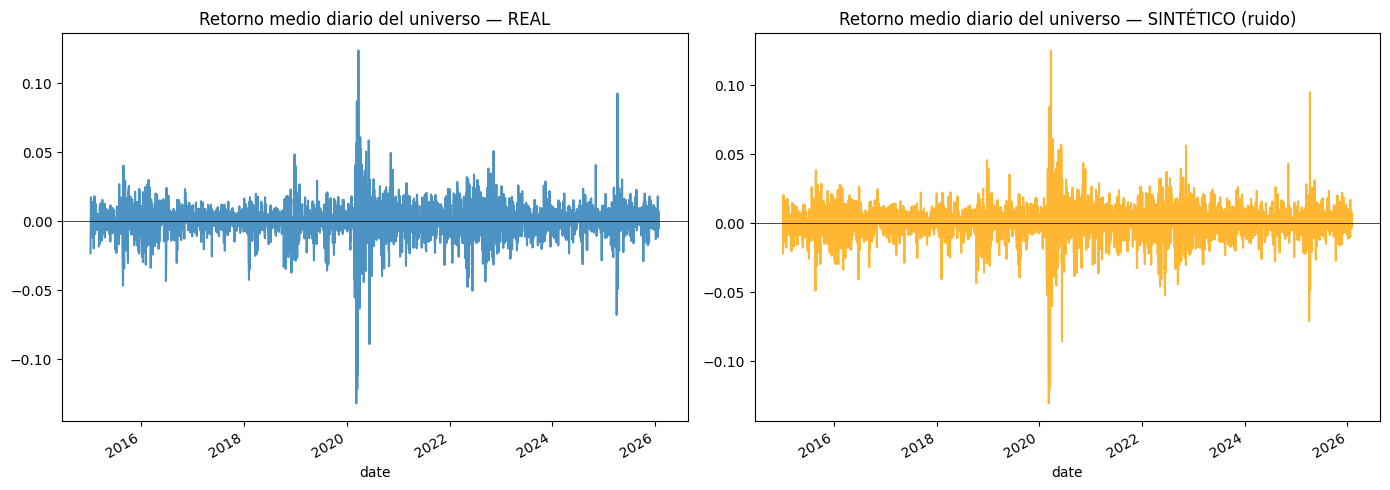

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

returns_real.mean(axis=1).plot(ax=axes[0], title="Retorno medio diario del universo — REAL", alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.5)

returns_synthetic.mean(axis=1).plot(ax=axes[1], title="Retorno medio diario del universo — SINTÉTICO (ruido)", alpha=0.8, color="orange")
axes[1].axhline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

**Lectura:** con `noise_std_ratio=0.2`, el `std_ratio` queda entre 1.01 y
1.03 en los 30 activos — el sintético tiene solo un 1-3% más de volatilidad
que el real, consistente con la predicción teórica de ~2% de exceso
($\sqrt{1+0.2^2}-1$). Las medias también se mantienen razonablemente
cercanas, aunque con más dispersión que las desviaciones (el ruido
gaussiano de media cero no debería sesgar la media a largo plazo, la
diferencia observada es ruido de muestra).

## 5. Comparación de la matriz de correlaciones

Esta es la comparación más relevante de cara al objetivo final del taller
(predecir la matriz de covarianzas): si el sintético no conserva bien la
estructura de correlación entre activos, no servirá para mejorar la
predicción de Σ.

In [7]:
corr_real = returns_real.corr()
corr_synth = returns_synthetic.corr()

corr_diff = (corr_real - corr_synth).abs()

print(f"Diferencia media absoluta entre correlaciones real y sintética: {corr_diff.values[np.triu_indices_from(corr_diff.values, k=1)].mean():.4f}")
print(f"Diferencia máxima: {corr_diff.values[np.triu_indices_from(corr_diff.values, k=1)].max():.4f}")

Diferencia media absoluta entre correlaciones real y sintética: 0.0053
Diferencia máxima: 0.0214


**Lectura:** una diferencia media de 0.0053 y máxima de 0.0214 en la
matriz de correlaciones indica que el sintético conserva muy bien la
estructura conjunta entre los 30 activos — las betas reales (que no se
tocan en este modelo) hacen la mayor parte del trabajo de mantener la
correlación, y el ruido moderado (ratio=0.2) apenas la perturba. Este
0.0053 es el número de referencia para comparar los siguientes modelos
generativos (Notebook 4-6): si consiguen bajar de aquí, aportan una mejora
real sobre el baseline más simple.

## 6. Guardado del dataset sintético

Se guarda con un sufijo `_noise` para poder distinguirlo de los datasets
que generen los siguientes modelos (gaussiana, VAE, AR/GRU) y poder
mezclarlos con los reales en distintas proporciones (Notebook 7).

In [8]:
returns_synthetic.to_parquet("../data/processed/returns_synthetic_noise.parquet")
print("Guardado en data/processed/returns_synthetic_noise.parquet")

Guardado en data/processed/returns_synthetic_noise.parquet


## 7. Conclusión

- Se implementó el modelo de referencia obligatorio del taller: ruido
  gaussiano añadido a cada componente de la descomposición factorial
  (mercado, sector, idiosincrático), escalado según la volatilidad
  histórica de cada uno.
- **Ajuste del hiperparámetro `noise_std_ratio`:** una primera prueba con
  `ratio=1.0` produjo un exceso sistemático de volatilidad del ~41% en
  todos los activos (confirmando la predicción matemática de
  $\sqrt{2}\approx 1.41$ para ruido con la misma desviación que la señal),
  y una diferencia media de correlación real-sintético de 0.042 (máxima
  0.223). Se corrigió bajando a `ratio=0.2`: el exceso de volatilidad se
  redujo al ~2% (`std_ratio` entre 1.01 y 1.03 en los 30 activos), y la
  diferencia de correlación bajó a 0.0053 de media (máxima 0.0214) — una
  mejora de 8-10x en preservar la estructura conjunta entre activos.
- Con `ratio=0.2`, el modelo de ruido resulta un baseline razonablemente
  competente (no un baseline "de risa"), lo cual es positivo para la
  comparación final: si los modelos más sofisticados (gaussiana, VAE,
  AR/GRU) lo superan, será una mejora real y defendible, no inflada por
  comparar contra un baseline exageradamente malo.
- Este resultado (diferencia de correlación ≈ 0.005) sirve de referencia
  numérica concreta para valorar el resto de modelos generativos
  (Notebook 4: Gaussiana ajustada, Notebook 5: VAE, Notebook 6: AR/GRU).

**Siguiente paso (Notebook 4):** modelo generativo 2 — Gaussiana
multivariante ajustada a los datos reales ("no tan tonto", $x \sim N(\mu,
\Sigma)$).